# Blur & image-quality forensics

After a full inference run, `eval_runs.csv` holds one row per inference (per photo × run) for field labels/scores, not just the 2/3 vote.

Outputs for this notebook go under **`research/eval/results/blur_testing/`** (see `results/blur_testing/README.md`). Run [`real_photo_characterizer.py`](./real_photo_characterizer.py) with `--out results/blur_testing` (from `research/eval`) so you get `photo_attributes.csv` plus `eval_runs.csv`, `attribute_ranking.csv`, and `summary.md` after a full eval.


In [ ]:
# ! python3 real_photo_characterizer.py --photos /Users/danfinkel/Documents/kaggle/gemma4/civics/blur_test/clean  --attributes-only
! python3 real_photo_characterizer.py --photos /Users/danfinkel/Documents/kaggle/gemma4/civics/blur_test/all  --out results/blur_testing --backend ollama


Photo 1/34: IMG_9057.HEIC → attributes extracted →   Ollama input: IMG_9057.jpg → 768×1024 JPEG (~106 KB, max edge 1024px)
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
  … still waiting on Ollama (15s elapsed). First vision request often loads a large model; CPU inference is slow.
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
inference: 3/3 runs → label: pass (3/3 deadline exact)
Photo 2/34: IMG_9058.HEIC → attributes extracted →   Ollama input: IMG_9058.jpg → 768×1024 JPEG (~89 KB, max edge 1024px)
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into memory.
  HTTP POST /api/chat (heartbeat every 15s until response). First run may spend minutes loading the model into

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def _find_eval_dir() -> Path:
    """Directory containing `real_photo_characterizer.py` (usually `research/eval`)."""
    cwd = Path.cwd().resolve()
    if (cwd / "real_photo_characterizer.py").is_file():
        return cwd
    for sub in (cwd / "research" / "eval",):
        if (sub / "real_photo_characterizer.py").is_file():
            return sub
    for anc in (cwd, *cwd.parents):
        d = anc / "research" / "eval"
        if (d / "real_photo_characterizer.py").is_file():
            return d
    return cwd


def _find_photo_attributes_csv() -> Path:
    """Prefer `results/blur_testing/`, then legacy `real_photo_analysis/`."""
    ev = _find_eval_dir()
    for sub in ("blur_testing", "real_photo_analysis"):
        p = ev / "results" / sub / "photo_attributes.csv"
        if p.is_file():
            return p
    raise FileNotFoundError(
        f"Could not find photo_attributes.csv in {ev}/results/blur_testing/ or "
        f".../real_photo_analysis/. Run: python3 real_photo_characterizer.py ... "
        f"--out results/blur_testing --backend ollama (cwd={Path.cwd()})"
    )


CSV = _find_photo_attributes_csv()
RESULT_DIR = CSV.parent
CONVERTED = RESULT_DIR / "converted"

METRIC_COLS = [
    # Keep in sync with real_photo_characterizer.ATTRIBUTE_COLS (excludes width_px / height_px)
    "laplacian_variance",
    "tenengrad_variance",
    "laplacian_variance_center",
    "tenengrad_variance_center",
    "mean_luminance",
    "luminance_std",
    "histogram_entropy",
    "michelson_contrast",
    "rms_contrast",
    "rotation_angle",
    "noise_estimate",
    "file_size_kb",
    "white_region_ratio",
    "document_coverage_ratio",
    "edge_density",
    "center_edge_density",
    "shadow_ratio",
    "quadrant_luminance_variance",
    "min_quadrant_luminance",
    "quadrant_luminance_ratio",
    "horizontal_blur_ratio",
    "gradient_direction_entropy",
    "document_touches_edge",
    "document_aspect_ratio",
    "frame_aspect_ratio",
    "document_center_offset",
]


In [14]:
df = pd.read_csv(CSV)
print(f"Loaded {len(df)} rows from {CSV}")
df.head()

Loaded 34 rows from /Users/danfinkel/github/civics/research/eval/results/blur_testing/photo_attributes.csv


,filename,laplacian_variance,tenengrad_variance,laplacian_variance_center,tenengrad_variance_center,mean_luminance,luminance_std,histogram_entropy,michelson_contrast,rms_contrast,...,horizontal_blur_ratio,gradient_direction_entropy,document_touches_edge,document_aspect_ratio,frame_aspect_ratio,document_center_offset,width_px,height_px,pass_rate,label
0,IMG_9057.jpg,60.724612,3292.394192,149.798655,8324.550677,147.177692,62.078441,4.527738,1.0,0.243445,...,0.9770,5.1435,0,0.9180,0.75,0.0207,4284,5712,1.0,pass
1,IMG_9058.jpg,71.368720,3294.046019,170.362593,8405.508963,137.210420,58.882653,5.138437,1.0,0.230912,...,1.1649,5.1537,0,0.7813,0.75,0.0081,4284,5712,1.0,pass
2,IMG_9059.jpg,122.754513,4245.836330,218.364461,7517.233664,128.467395,65.563426,5.266828,1.0,0.257111,...,1.3482,5.1569,0,0.7866,0.75,0.0176,4284,5712,0.0,fail
3,IMG_9060.jpg,50.546840,2885.206626,97.315943,5508.556292,150.056531,60.913514,4.981850,1.0,0.238877,...,1.1126,5.1447,0,0.7802,0.75,0.0348,4284,5712,1.0,pass
4,IMG_9061.jpg,43.472027,2747.740230,77.819063,4837.166233,148.137207,61.310772,5.095314,1.0,0.240434,...,1.0624,5.1513,1,0.8923,0.75,0.1102,4284,5712,1.0,pass


## 1) Summary and correlations

Distributions and Pearson correlations across numeric metrics. Global vs **center (60% crop)** sharpness can diverge when the document occupies only part of the frame.

,count,mean,std,min,25%,50%,75%,max
laplacian_variance,34.0,88.007,77.581,12.626,33.588,48.087,129.989,291.160
tenengrad_variance,34.0,3648.730,2310.349,793.395,2344.433,2826.806,4573.854,10262.198
laplacian_variance_center,34.0,137.796,112.626,18.464,51.504,87.968,205.976,518.816
tenengrad_variance_center,34.0,5716.668,3025.062,679.464,3715.554,5309.979,7603.233,15621.661
mean_luminance,34.0,147.921,9.467,126.383,143.692,149.943,154.711,161.723
luminance_std,34.0,68.611,7.897,57.068,62.216,66.102,75.810,83.692
histogram_entropy,34.0,4.846,0.247,4.333,4.715,4.814,5.058,5.267
michelson_contrast,34.0,1.000,0.000,1.000,1.000,1.000,1.000,1.000
rms_contrast,34.0,0.269,0.031,0.224,0.244,0.259,0.297,0.328
rotation_angle,34.0,0.676,14.641,-40.000,-4.000,0.500,2.750,36.000


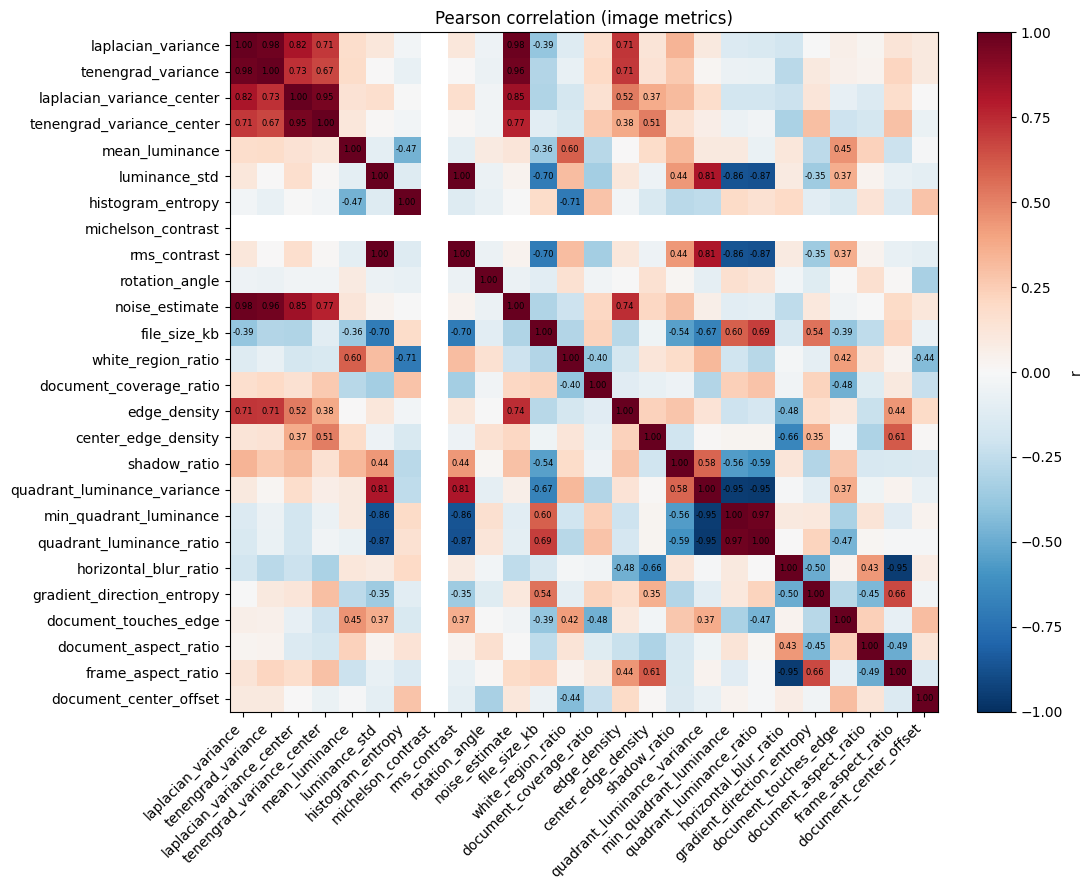

In [15]:
summary = df[METRIC_COLS].describe().T
display(summary.round(3))

corr = df[METRIC_COLS].corr(method="pearson")
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(METRIC_COLS)))
ax.set_yticks(range(len(METRIC_COLS)))
ax.set_xticklabels(METRIC_COLS, rotation=45, ha="right")
ax.set_yticklabels(METRIC_COLS)
ax.set_title("Pearson correlation (image metrics)")
for i in range(len(METRIC_COLS)):
    for j in range(len(METRIC_COLS)):
        v = corr.values[i, j]
        if not np.isnan(v) and abs(v) >= 0.35:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6, color="black")
plt.colorbar(im, ax=ax, fraction=0.046, label="r")
plt.tight_layout()
plt.show()

## 1b) New image metrics vs. pass/fail (2/3 deadline vote)

Coverage, shadow, directional blur, and frame metrics from `real_photo_characterizer`. **Pass** and **fail** (2/3 deadline) are **overlaid density histograms** per metric. If `label` is missing, a single distribution is shown.


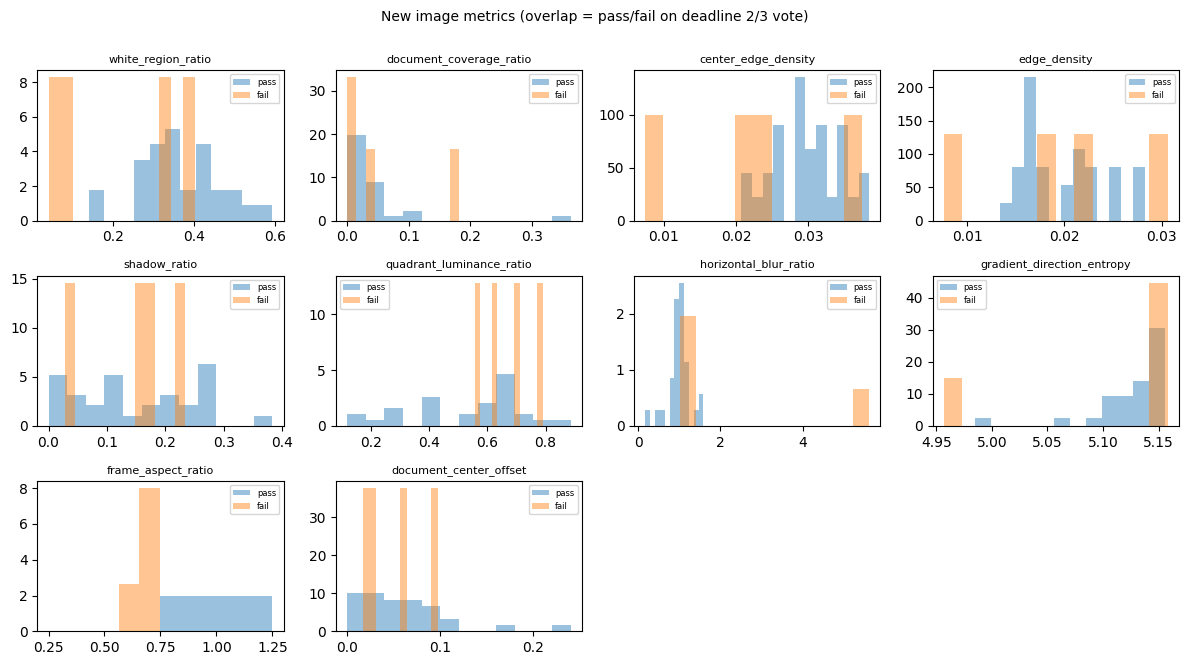

In [24]:
# New metrics: pass vs fail (2/3 deadline). Re-run characterizer if columns are missing.
NEW_METRIC_PLOT = [
    "white_region_ratio", "document_coverage_ratio", "center_edge_density", "edge_density",
    "shadow_ratio", "quadrant_luminance_ratio", "horizontal_blur_ratio", "gradient_direction_entropy",
    "frame_aspect_ratio", "document_center_offset",
]
cols = [c for c in NEW_METRIC_PLOT if c in df.columns]
if not cols:
    print("No new metric columns in df — re-run with latest real_photo_characterizer.py")
else:
    labs = (
        [l for l in ("pass", "fail") if l in set(df["label"].dropna().unique())]
        if "label" in df.columns
        else []
    )
    n, nrows = len(cols), int(np.ceil(len(cols) / 4.0))
    fig, axes = plt.subplots(nrows, 4, figsize=(12, 2.2 * nrows), squeeze=False)
    for k, col in enumerate(cols):
        ax = axes[k // 4][k % 4]
        if len(labs) >= 1:
            for lab in labs:
                v = df.loc[df["label"] == lab, col].dropna()
                if len(v) < 1:
                    continue
                if int(v.nunique()) <= 3:
                    b = int(v.max() - v.min() + 1) + 1
                    b = min(b, 8) if b > 0 else 3
                else:
                    b = 12
                ax.hist(v, bins=b, alpha=0.45, label=lab, density=True)
            ax.legend(fontsize=6)
        else:
            ax.hist(df[col].dropna(), bins=14, color="0.35", edgecolor="white", alpha=0.9, density=True)
        ax.set_title(col, fontsize=8)
    for j in range(n, nrows * 4):
        axes[j // 4][j % 4].set_visible(False)
    fig.suptitle("New image metrics (overlap = pass/fail on deadline 2/3 vote)", y=1.0, fontsize=10)
    plt.tight_layout()
    plt.show()


## 2) Sharpness ranking and scatter

Sort photos by **Tenengrad (center)** as a text-focused edge-energy proxy; compare with global Laplacian (typical blur detector input).

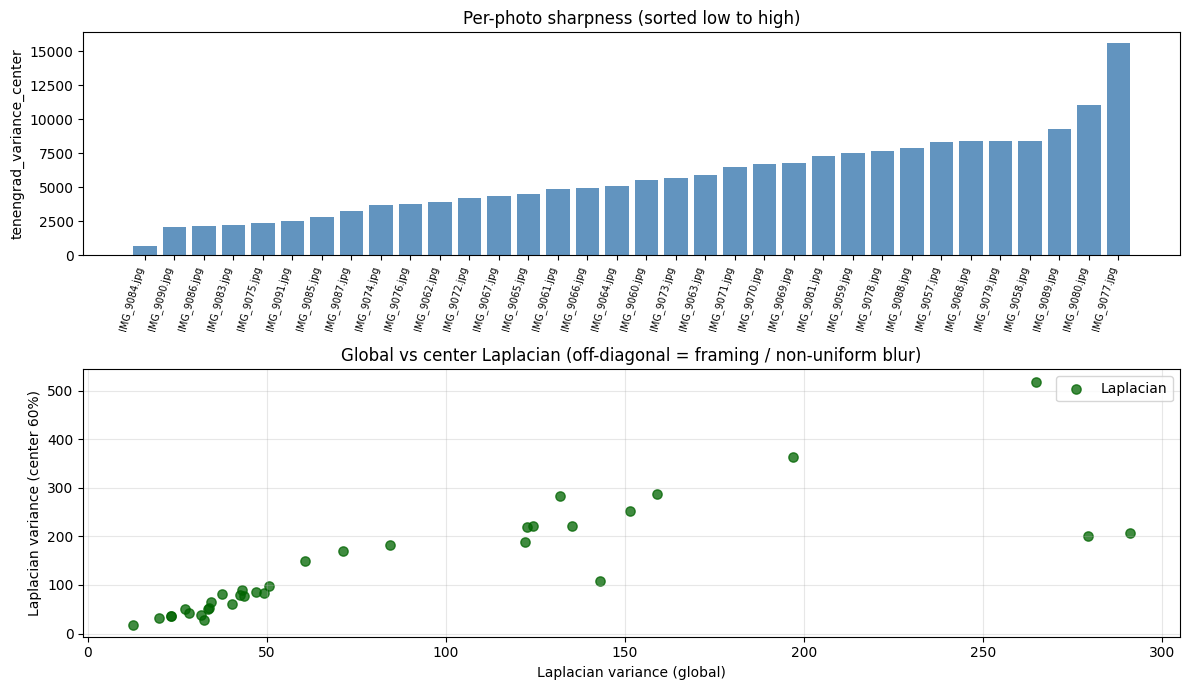

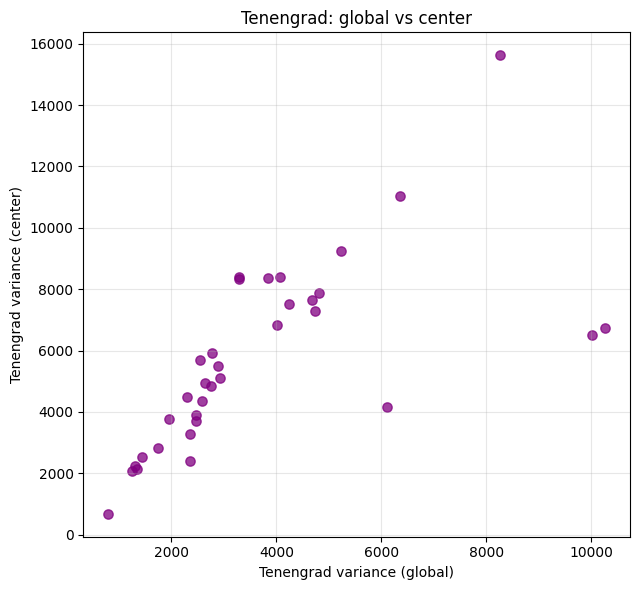

In [16]:
key = "tenengrad_variance_center"
d_sort = df.sort_values(key, ascending=True).reset_index(drop=True)
x = np.arange(len(d_sort))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [1, 1.2]})
axes[0].bar(x, d_sort[key], color="steelblue", alpha=0.85)
axes[0].set_ylabel(key)
axes[0].set_title("Per-photo sharpness (sorted low to high)")
axes[0].set_xticks(x[:: max(1, len(x) // 20)])
axes[0].set_xticklabels(d_sort["filename"].iloc[:: max(1, len(x) // 20)], rotation=75, ha="right", fontsize=7)

axes[1].scatter(d_sort["laplacian_variance"], d_sort["laplacian_variance_center"], alpha=0.75, s=45, c="darkgreen", label="Laplacian")
axes[1].set_xlabel("Laplacian variance (global)")
axes[1].set_ylabel("Laplacian variance (center 60%)")
axes[1].set_title("Global vs center Laplacian (off-diagonal = framing / non-uniform blur)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(df["tenengrad_variance"], df["tenengrad_variance_center"], alpha=0.75, s=45, c="purple")
ax.set_xlabel("Tenengrad variance (global)")
ax.set_ylabel("Tenengrad variance (center)")
ax.set_title("Tenengrad: global vs center")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3) Lighting and noise

Low light often raises **noise** without changing edge energy the same way blur does — useful when triaging root causes.

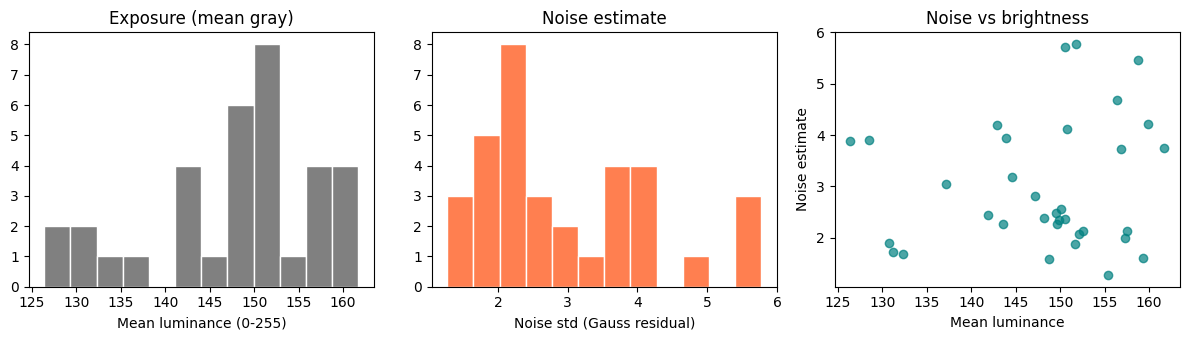

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(df["mean_luminance"], bins=12, color="gray", edgecolor="white")
axes[0].set_xlabel("Mean luminance (0-255)")
axes[0].set_title("Exposure (mean gray)")

axes[1].hist(df["noise_estimate"], bins=12, color="coral", edgecolor="white")
axes[1].set_xlabel("Noise std (Gauss residual)")
axes[1].set_title("Noise estimate")

axes[2].scatter(df["mean_luminance"], df["noise_estimate"], alpha=0.7, c="teal")
axes[2].set_xlabel("Mean luminance")
axes[2].set_ylabel("Noise estimate")
axes[2].set_title("Noise vs brightness")
plt.tight_layout()
plt.show()

## 4) Extremes (optional thumbnails)

If `converted/` JPEGs exist, show the **lowest / highest** center-Tenengrad frames for a quick sanity check.

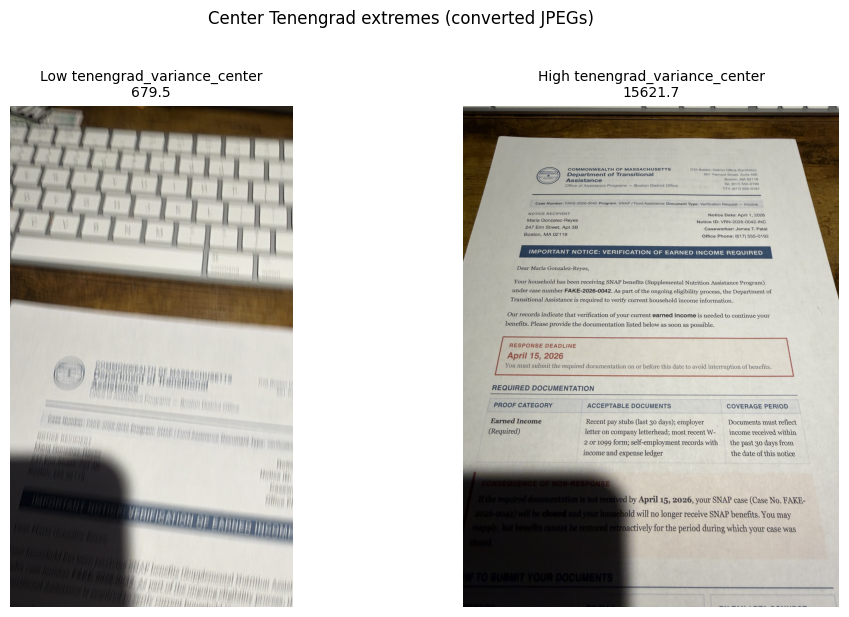

In [18]:
from matplotlib import image as mpimg

key = "tenengrad_variance_center"
lo = df.loc[df[key].idxmin()]
hi = df.loc[df[key].idxmax()]
paths = []
for row, title in ((lo, f"Low {key}"), (hi, f"High {key}")):
    p = CONVERTED / row["filename"]
    paths.append((p, title, row[key]))

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, (p, title, val) in zip(axes, paths):
    if p.is_file():
        im = mpimg.imread(p)
        ax.imshow(im)
        ax.set_title(f"{title}\n{val:.1f}", fontsize=10)
    else:
        ax.text(0.5, 0.5, f"Missing:\n{p}", ha="center", va="center")
        ax.set_axis_off()
    ax.axis("off")
plt.suptitle("Center Tenengrad extremes (converted JPEGs)", y=1.02)
plt.tight_layout()
plt.show()

## 5) After a full LLM run

If you re-run `real_photo_characterizer.py` **without** `--attributes-only`, load `attribute_ranking.csv` and merge labels for pass/fail-colored scatters.

,attribute,pass_mean,fail_mean,cohens_d,p_value,significant
0,histogram_entropy,4.816,5.070,1.149,0.0484,True
1,white_region_ratio,0.368,0.213,1.070,0.1047,False
2,quadrant_luminance_variance,1507.678,538.624,0.948,0.1047,False
3,quadrant_luminance_ratio,0.530,0.669,0.885,0.2183,False
4,min_quadrant_luminance,95.217,113.780,0.826,0.4533,False
5,horizontal_blur_ratio,1.007,2.273,0.795,0.0577,False
6,document_touches_edge,0.867,0.500,0.771,0.0819,False
7,mean_luminance,149.021,139.678,0.758,0.2183,False
8,center_edge_density,0.030,0.023,0.752,0.1625,False
9,frame_aspect_ratio,0.750,0.703,0.707,0.0081,True


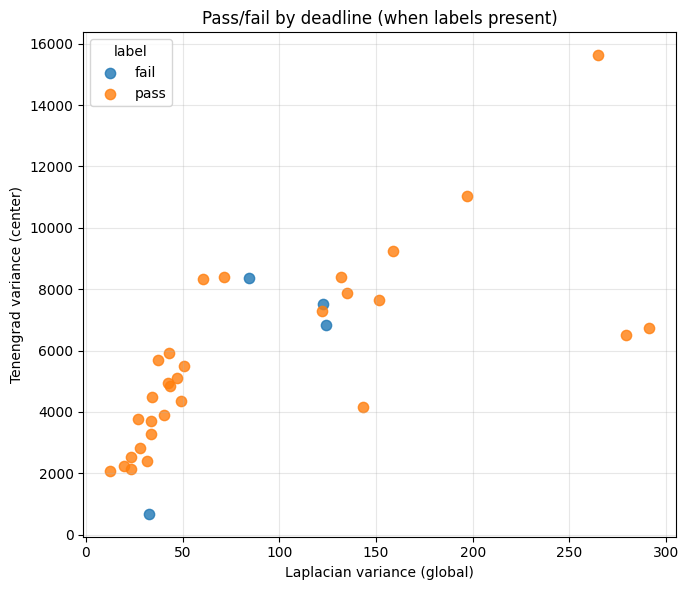

In [19]:
rank_path = RESULT_DIR / "attribute_ranking.csv"
if rank_path.is_file():
    ranking = pd.read_csv(rank_path)
    display(ranking)
else:
    print(f"No {rank_path.name} yet (run full pipeline, not --attributes-only).")

if "label" in df.columns and df["label"].notna().any():
    has = df["label"].notna()
    sub = df.loc[has]
    fig, ax = plt.subplots(figsize=(7, 6))
    for lab, g in sub.groupby("label"):
        ax.scatter(g["laplacian_variance"], g["tenengrad_variance_center"], label=lab, alpha=0.8, s=55)
    ax.set_xlabel("Laplacian variance (global)")
    ax.set_ylabel("Tenengrad variance (center)")
    ax.legend(title="label")
    ax.set_title("Pass/fail by deadline (when labels present)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No pass/fail labels in CSV yet.")

## 6) Per-run evals (each inference, not the 2/3 aggregate)

`eval_runs.csv` (written next to `photo_attributes.csv` on a full characterizer run) has one row per `(filename, run)` with `critical_deadline_exact` and per-field `*_label` / `*_score` from the D01 rubric. Merge with photo attributes to relate pixel metrics to every single model call.


In [20]:
ERUNS = RESULT_DIR / "eval_runs.csv"
runs = None
if not ERUNS.is_file():
    print(
        "No eval_runs.csv in RESULT_DIR. Re-run `real_photo_characterizer` without "
        "--attributes-only; the script writes one row per inference run."
    )
else:
    runs = pd.read_csv(ERUNS)
    n_runs = runs.groupby("filename").size()
    n_per = int(n_runs.iloc[0]) if len(n_runs) else 0
    print(
        f"Loaded {len(runs)} run rows = {runs['filename'].nunique()} photos × {n_per} runs"
    )

    merged = runs.merge(
        df[["filename", "label", "pass_rate"] + [c for c in METRIC_COLS if c in df.columns]],
        on="filename",
        how="left",
    )
    display(merged.sort_values(["filename", "run"]).head(15))

    by_run = (
        runs.groupby("run", as_index=True)["critical_deadline_exact"]
        .agg(rate_exact="mean", n_exact="sum", n="count")
        .round(3)
    )
    print("Deadline exact by run index (0 = first call on that photo):")
    display(by_run)

    per = (
        runs.groupby("filename", as_index=False)["critical_deadline_exact"]
        .agg(n_exact="sum", n="count")
    )
    per["all_same"] = (per["n_exact"] == 0) | (per["n_exact"] == per["n"])
    mixed = per.loc[~per["all_same"]]
    print("Photos with mixed outcomes across the 3 runs (variance in deadline exact):", len(mixed))
    if len(mixed):
        display(
            mixed.merge(df[["filename", "label", "laplacian_variance_center"]], on="filename")
        )


Loaded 102 run rows = 34 photos × 3 runs


,filename,run,critical_deadline_exact,case_number_correct_field,case_number_label,case_number_score,caseworker_name_correct_field,caseworker_name_label,caseworker_name_score,consequence_correct_field,...,shadow_ratio,quadrant_luminance_variance,min_quadrant_luminance,quadrant_luminance_ratio,horizontal_blur_ratio,gradient_direction_entropy,document_touches_edge,document_aspect_ratio,frame_aspect_ratio,document_center_offset
0,IMG_9057.jpg,0,True,True,exact,2.0,True,exact,2.0,True,...,0.002432,47.278044,135.397231,0.8867,0.9770,5.1435,0,0.9180,0.75,0.0207
1,IMG_9057.jpg,1,True,True,exact,2.0,True,exact,2.0,True,...,0.002432,47.278044,135.397231,0.8867,0.9770,5.1435,0,0.9180,0.75,0.0207
2,IMG_9057.jpg,2,True,True,exact,2.0,True,exact,2.0,True,...,0.002432,47.278044,135.397231,0.8867,0.9770,5.1435,0,0.9180,0.75,0.0207
3,IMG_9058.jpg,0,True,True,transcription_error,0.0,False,misattribution,-1.0,True,...,0.100446,431.496557,114.579236,0.6940,1.1649,5.1537,0,0.7813,0.75,0.0081
4,IMG_9058.jpg,1,True,True,transcription_error,0.0,False,misattribution,-1.0,True,...,0.100446,431.496557,114.579236,0.6940,1.1649,5.1537,0,0.7813,0.75,0.0081
5,IMG_9058.jpg,2,True,True,transcription_error,0.0,False,misattribution,-1.0,True,...,0.100446,431.496557,114.579236,0.6940,1.1649,5.1537,0,0.7813,0.75,0.0081
6,IMG_9059.jpg,0,False,True,unreadable,0.0,True,unreadable,0.0,True,...,0.157324,344.893228,109.710256,0.6981,1.3482,5.1569,0,0.7866,0.75,0.0176
7,IMG_9059.jpg,1,False,True,unreadable,0.0,True,unreadable,0.0,True,...,0.157324,344.893228,109.710256,0.6981,1.3482,5.1569,0,0.7866,0.75,0.0176
8,IMG_9059.jpg,2,False,True,unreadable,0.0,True,unreadable,0.0,True,...,0.157324,344.893228,109.710256,0.6981,1.3482,5.1569,0,0.7866,0.75,0.0176
9,IMG_9060.jpg,0,True,True,exact,2.0,True,exact,2.0,True,...,0.099065,746.568384,116.725144,0.6435,1.1126,5.1447,0,0.7802,0.75,0.0348


Deadline exact by run index (0 = first call on that photo):


,rate_exact,n_exact,n
run,,,
0,0.882,30,34
1,0.882,30,34
2,0.882,30,34


Photos with mixed outcomes across the 3 runs (variance in deadline exact): 0


In [21]:
# Per-run LOO: binary target = this run's critical_deadline_exact (60 rows for 20×3)
if ERUNS.is_file() and runs is not None and len(runs) >= 6:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score
    from sklearn.model_selection import LeaveOneOut
    from sklearn.preprocessing import StandardScaler

    m2 = runs.merge(
        df[["filename"] + [c for c in METRIC_COLS if c in df.columns]],
        on="filename",
    )
    y = m2["critical_deadline_exact"].astype(int).to_numpy()
    X = m2[METRIC_COLS].reindex(columns=METRIC_COLS).fillna(0).to_numpy()
    Xs = StandardScaler().fit_transform(X)
    loo = LeaveOneOut()
    lr = LogisticRegression(max_iter=2000)
    pred = []
    for tr, te in loo.split(Xs):
        yt = y[tr]
        if np.all(yt == 0) or np.all(yt == 1):
            pred.append(int(yt[0]))
            continue
        try:
            lr.fit(Xs[tr], yt)
            pred.append(int(lr.predict(Xs[te])[0]))
        except ValueError:
            pred.append(int(round(yt.mean())))
    acc = float(accuracy_score(y, np.array(pred)))
    print("LOO accuracy (per-run rows, pred critical_deadline_exact from metrics):", round(acc, 3))
    print("Baseline (always predict majority class):", round(max(y.mean(), 1 - y.mean()), 3))
else:
    print("Skip: need eval_runs.csv with run rows and merged metrics.")



LOO accuracy (per-run rows, pred critical_deadline_exact from metrics): 1.0
Baseline (always predict majority class): 0.882


## 7) Field-label heatmap (photos × fields)

Photos as rows, D01 fields as columns, **color + text** encode the rubric label. This makes several things visible at once: how robust the deadline field is vs other fields, a gradient of reliability across fields (visual salience), and a **failure signature** on the photos that miss the 2/3 deadline vote (fail rows first). Cells aggregate with a **majority vote** across the three Ollama runs per photo.


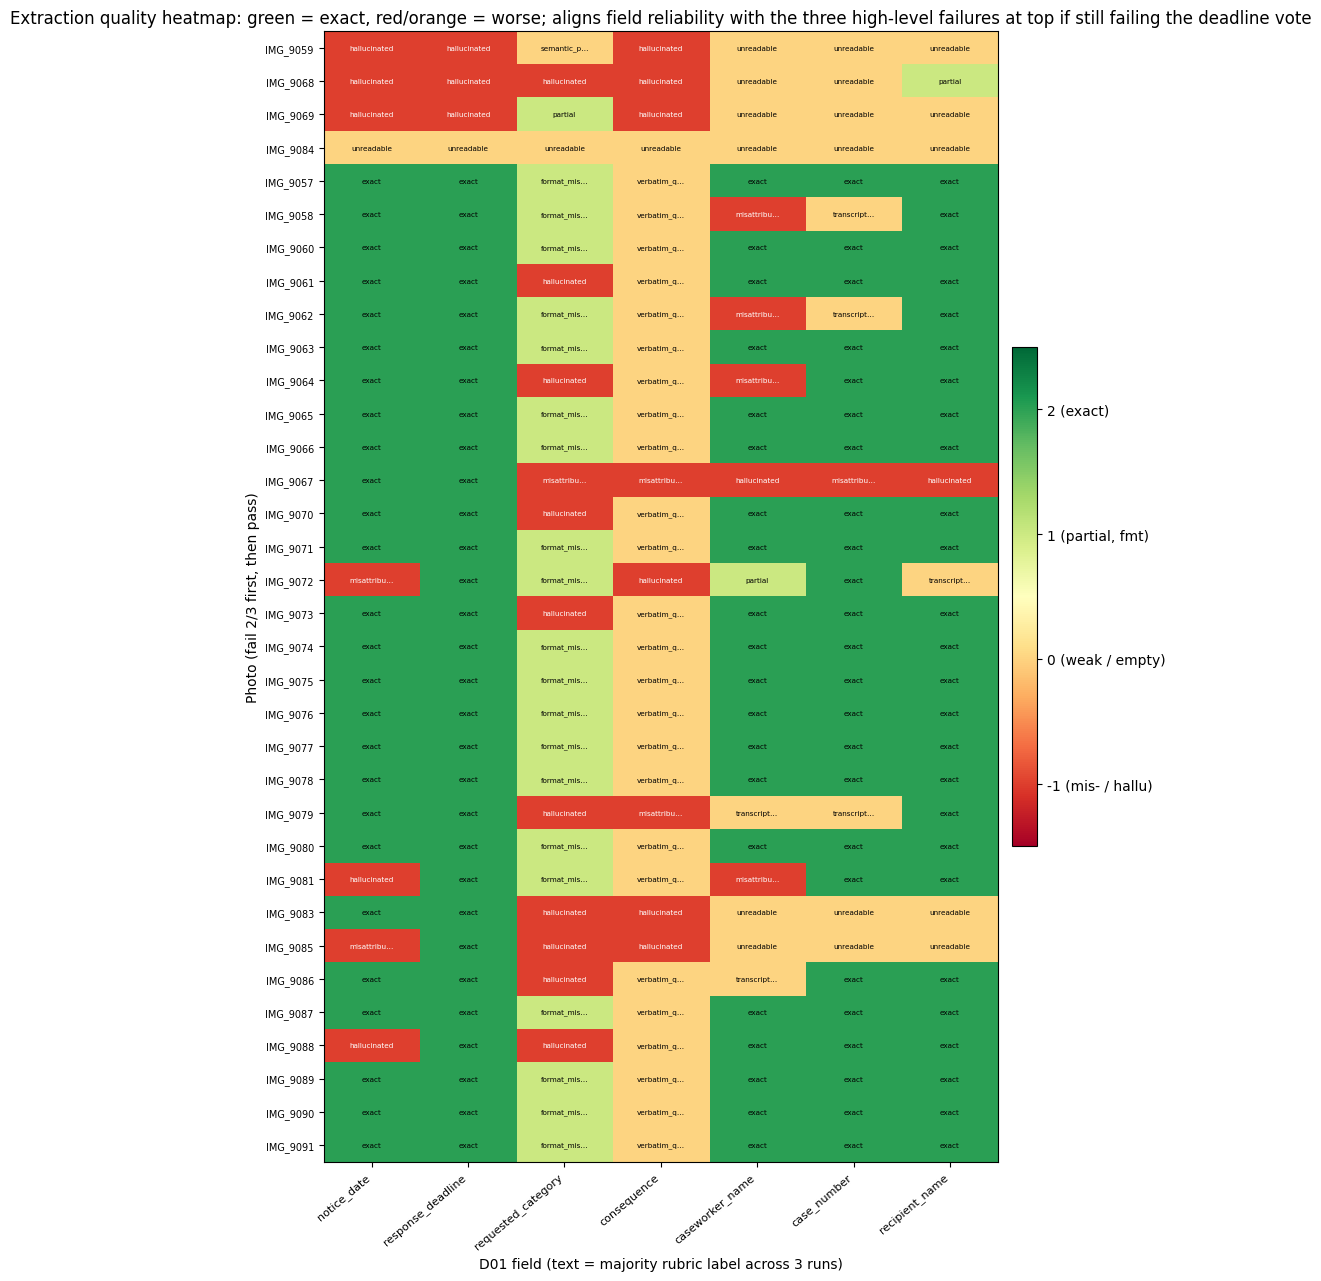

Each cell: most common *label* across 3 Ollama runs. Color: rubric score band (runner LABEL_SCORES).


In [22]:
# Field-label heatmap: photos (rows) × D01 fields (columns); color = rubric label (majority across 3 runs)
from collections import Counter

# Rubric order matches research/eval/runner.py LABEL_SCORES
LABEL_TO_SCORE = {
    "exact": 2,
    "partial": 1,
    "format_mismatch": 1,
    "transcription_error": 0,
    "unreadable": 0,
    "missing": 0,
    "semantic_paraphrase": 0,
    "verbatim_quote": 0,
    "misattribution": -1,
    "hallucinated": -1,
}

FIELD_ORDER = [
    "notice_date",
    "response_deadline",
    "requested_category",
    "consequence",
    "caseworker_name",
    "case_number",
    "recipient_name",
]

_erun = RESULT_DIR / "eval_runs.csv"
if not _erun.is_file():
    print("Need eval_runs.csv — re-run the characterizer without --attributes-only.")
else:
    _r = runs if "runs" in dir() and runs is not None else pd.read_csv(_erun)
    label_cols = [f"{f}_label" for f in FIELD_ORDER if f"{f}_label" in _r.columns]
    if not label_cols:
        print("No *_label columns in eval_runs — regenerate eval_runs.csv with current characterizer.")
    else:
        def _majority(series: pd.Series) -> str:
            vals = [str(x).strip() for x in series if pd.notna(x) and str(x).strip() != ""]
            if not vals:
                return ""
            return Counter(vals).most_common(1)[0][0]

        per_photo = _r.groupby("filename", sort=False).agg({c: _majority for c in label_cols}).reset_index()
        per_photo = per_photo.merge(
            df[["filename", "label"]],
            on="filename",
            how="left",
        )
        per_photo["_grp"] = per_photo["label"].map({"fail": 0, "pass": 1}).fillna(1)
        per_photo = per_photo.sort_values(["_grp", "filename"], ascending=[True, True])
        per_photo = per_photo.drop(columns=["_grp"])

        mat_l = per_photo.set_index("filename")[label_cols].copy()
        mat_l.columns = [c.replace("_label", "") for c in mat_l.columns]

        def _to_score(v):
            if v is None or (isinstance(v, float) and np.isnan(v)) or str(v).strip() == "":
                return np.nan
            return LABEL_TO_SCORE.get(str(v).strip(), np.nan)

        try:
            mat = mat_l.map(_to_score)  # pandas 2.1+
        except AttributeError:
            mat = mat_l.applymap(_to_score)  # pandas < 2.1
        data = mat.to_numpy(dtype=float)
        m = np.isnan(data)

        fig, ax = plt.subplots(figsize=(9.5, max(5.0, 0.38 * len(mat))))
        im = ax.imshow(
            np.ma.array(data, mask=m),
            aspect="auto",
            vmin=-1.5,
            vmax=2.5,
            interpolation="nearest",
            cmap="RdYlGn",
        )
        nrows, ncols = data.shape
        for i in range(nrows):
            for j in range(ncols):
                t = str(mat_l.iloc[i, j])
                if not t or t == "nan":
                    t = "—"
                if len(t) > 12:
                    t = t[:10] + "…"
                if m[i, j]:
                    ax.text(
                        j, i, t, ha="center", va="center", fontsize=5.2, color="0.2"
                    )
                else:
                    arr = im.cmap(
                        im.norm(data[i, j])
                    )[:3]
                    lum = 0.299 * arr[0] + 0.587 * arr[1] + 0.114 * arr[2]
                    tc = "white" if lum < 0.45 else "black"
                    ax.text(j, i, t, ha="center", va="center", fontsize=5.2, color=tc)

        ax.set_xticks(np.arange(ncols))
        ax.set_xticklabels(list(mat_l.columns), rotation=40, ha="right", fontsize=8)
        ax.set_yticks(np.arange(nrows))
        _names = [str(x).replace(".jpg", "") for x in mat_l.index.tolist()]
        ax.set_yticklabels(_names, fontsize=7)
        ax.set_xlabel("D01 field (text = majority rubric label across 3 runs)")
        ax.set_ylabel("Photo (fail 2/3 first, then pass)")
        ax.set_title(
            "Extraction quality heatmap: green = exact, red/orange = worse; "
            "aligns field reliability with the three high-level failures at top if still failing the deadline vote"
        )
        cbar = plt.colorbar(
            im, ax=ax, fraction=0.035, pad=0.02, ticks=[-1, 0, 1, 2]
        )
        cbar.ax.set_yticklabels(
            ["-1 (mis- / hallu)", "0 (weak / empty)", "1 (partial, fmt)", "2 (exact)"]
        )
        plt.tight_layout()
        plt.show()

        print("Each cell: most common *label* across 3 Ollama runs. Color: rubric score band (runner LABEL_SCORES).")


## 8) Logistic regression (exploratory)

Photo-level: standardized **metric columns** → probability of **fail** (2/3 `critical_deadline_exact` vote). The cell prints coefficients, a table with **p_fail_insample** and **p_fail_loo** (leave-one-out, less optimistic), and stores **PRED_REG_DF** and **REG_BUNDLE** (fitted model, scaler, feature list) for when you re-run with more data.


In [23]:
# Exploratory logistic regression: standardized visual metrics -> P(photo "fail" on 2/3 deadline vote)
# Small n — in-sample proba is optimistic; use p_fail_loo for a slightly less overfit signal. Re-fit when n grows.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

cols = [c for c in METRIC_COLS if c in df.columns]
if "label" not in df.columns or df["label"].nunique() < 2 or len(cols) < 2:
    print("Need df with pass/fail label and metric columns (run the characterizer first).")
else:
    d = df.dropna(subset=["label"]).copy()
    y = (d["label"] == "fail").astype(int).to_numpy()
    X = d[cols].fillna(0.0).to_numpy()
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    m = LogisticRegression(
        max_iter=8000,
        C=0.5,
        class_weight="balanced",
        random_state=0,
    )
    m.fit(Xs, y)
    p_in = m.predict_proba(Xs)[:, 1]
    yhat = m.predict(Xs)

    loo = LeaveOneOut()
    p_loo = np.full(len(y), np.nan, dtype=float)
    for tr, te in loo.split(Xs):
        yt, ys = y[tr], y[te]
        if np.all(yt == 0) or np.all(yt == 1):
            p_loo[te[0]] = float(np.mean(yt))
            continue
        mlo = LogisticRegression(
            max_iter=8000, C=0.5, class_weight="balanced", random_state=0
        )
        mlo.fit(Xs[tr], yt)
        p_loo[te[0]] = float(mlo.predict_proba(Xs[te])[0, 1])

    pred_reg = d[["filename", "label"]].copy()
    pred_reg["p_fail_insample"] = p_in
    pred_reg["p_fail_loo"] = p_loo
    pred_reg["y_hat_fail_insample"] = yhat
    # LOO hard label at 0.5 (same threshold as default predict)
    pred_reg["y_hat_fail_loo"] = (p_loo >= 0.5).astype(int)
    pclip = pred_reg["p_fail_insample"].to_numpy().clip(1e-6, 1.0 - 1e-6)
    _ll = log_loss(y, pclip, labels=[0, 1])
    print(f"In-sample log loss (reference): {_ll:.4f}")

    coef_df = (
        pd.DataFrame({"attribute": cols, "coef": m.coef_.ravel()})
        .assign(abs_coef=lambda x: np.abs(x["coef"]))
        .sort_values("abs_coef", ascending=False)
    )
    inter = float(m.intercept_.ravel()[0])
    reg_bundle = {
        "model": m,
        "scaler": sc,
        "feature_cols": cols,
        "intercept": inter,
    }

    print(
        f"Fitted LogisticRegression (C=0.5, balanced, n={len(d)}). "
        f"Intercept: {inter:.4f}"
    )
    print("Top |coef| (standardized features):")
    display(coef_df.drop(columns="abs_coef").round(4))
    print("Per-photo predicted P(fail) (sort by LOO proba):")
    display(pred_reg.sort_values("p_fail_loo", ascending=False).round(4))

    n_loo_err = (pred_reg["y_hat_fail_loo"].to_numpy() != y).sum()
    print(
        f"LOO hard-classification error rate: {n_loo_err}/{len(y)} "
        "(for reference only at small n)"
    )

    # For new rows: Xn = new_df[REG_BUNDLE['feature_cols']].fillna(0); p_fail =
    # REG_BUNDLE['model'].predict_proba(REG_BUNDLE['scaler'].transform(Xn))[:, 1]
    PRED_REG_DF = pred_reg
    REG_BUNDLE = reg_bundle


In-sample log loss (reference): 0.1171
Fitted LogisticRegression (C=0.5, balanced, n=34). Intercept: -2.1273
Top |coef| (standardized features):


,attribute,coef
9,rotation_angle,0.9117
24,frame_aspect_ratio,-0.6279
20,horizontal_blur_ratio,0.6231
11,file_size_kb,0.5581
4,mean_luminance,-0.5567
12,white_region_ratio,-0.4098
2,laplacian_variance_center,0.3014
17,quadrant_luminance_variance,-0.3005
3,tenengrad_variance_center,0.2738
25,document_center_offset,-0.2650


Per-photo predicted P(fail) (sort by LOO proba):


,filename,label,p_fail_insample,p_fail_loo,y_hat_fail_insample,y_hat_fail_loo
1,IMG_9058.jpg,pass,0.4023,0.8336,0,1
12,IMG_9069.jpg,fail,0.9444,0.8032,1,1
2,IMG_9059.jpg,fail,0.9139,0.7922,1,1
5,IMG_9062.jpg,pass,0.4131,0.5603,0,1
20,IMG_9077.jpg,pass,0.2310,0.4914,0,0
28,IMG_9086.jpg,pass,0.2320,0.4470,0,0
0,IMG_9057.jpg,pass,0.1934,0.2809,0,0
33,IMG_9091.jpg,pass,0.1552,0.2733,0,0
3,IMG_9060.jpg,pass,0.1624,0.1975,0,0
7,IMG_9064.jpg,pass,0.1669,0.1875,0,0


LOO hard-classification error rate: 4/34 (for reference only at small n)
